In [1]:

# Imports
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Set path to event files
evts_path = "/Users/sambrown04/Documents/SURF/Events/2010_2010Events2stas"

In [3]:
def plot_event(event: pd.DataFrame, var="x") -> None:
    """
    Plot

    Parameters
    ----------
    event : pd.DataFrame
        Event to plot
    var : str
        Variable to plot.
        Valid options: 'x', 'y', 'z'
    """

    fig, ax1 = plt.subplots(figsize=(8, 6))
    times = pd.to_datetime(event["time"])
    sta_name_len = 4  # Length of station name for title
    plot_cols = [col for col in event if str(col).endswith(var)]

    first = True
    # Loop through stations for plotting
    for plot_col in plot_cols:
        demeaned_to_0 = (event[plot_col] - np.mean(event[plot_col])) - (
            event[plot_col][event.index[0]] - np.mean(event[plot_col])
        )
        if not np.isnan(event[plot_col][event.index[0]]):
            if first:
                ax2_dummy = demeaned_to_0
                first = False
            ax1.plot(times, demeaned_to_0, label=str(plot_col)[:sta_name_len])
    ax1.set_ylabel(f"{var.upper()} Displacement [meters]")
    ax1.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
    ax1.legend()
    ax1.set_xlim(times.iloc[0], times.iloc[-1])

    # Setup dates using second axis
    ax2 = ax1.twiny()
    ax2.xaxis.set_major_formatter(mdates.DateFormatter("%d %b %Y"))
    fig.subplots_adjust(bottom=0.10)
    ax2.set_frame_on(True)
    ax2.patch.set_visible(False)
    ax2.xaxis.set_ticks_position("bottom")
    ax2.xaxis.set_label_position("bottom")
    ax2.spines["bottom"].set_position(("outward", 20))
    ax2.set_xlabel("DateTime")

    # Need to plot something on ax2 to get the correct dates
    ax2.plot(times, ax2_dummy)
    for label in ax2.xaxis.get_ticklabels()[::2]:
        label.set_visible(False)

Loading 2010-12-08_16-05-00.evt
Loading 2010-03-06_19-05-00.evt


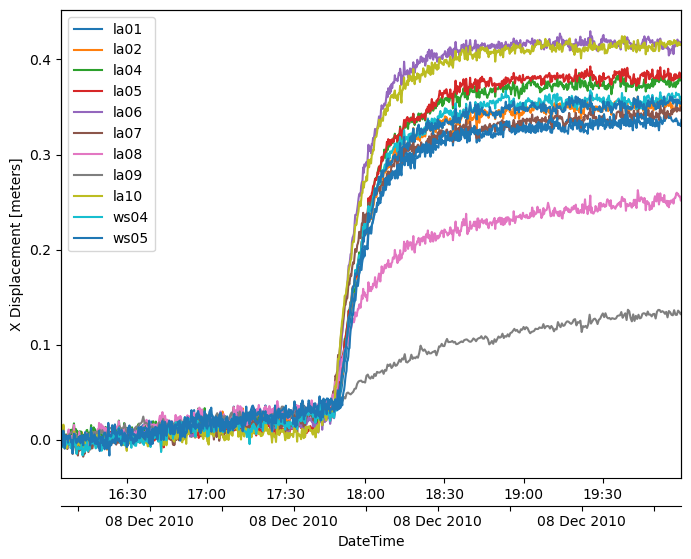

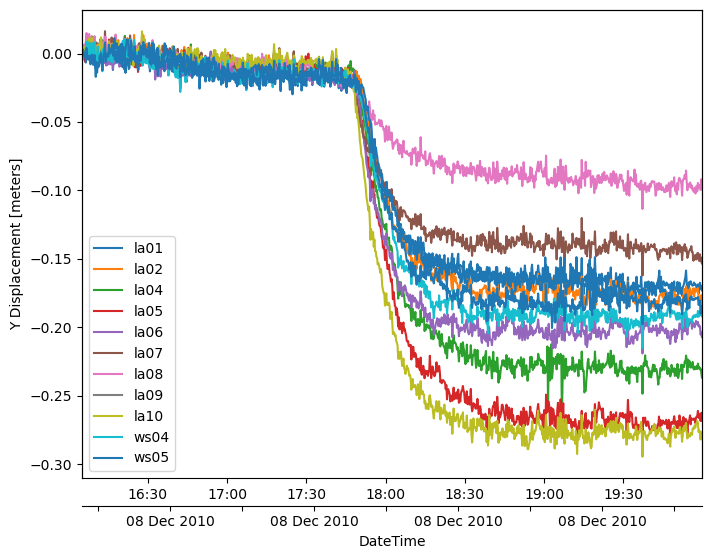

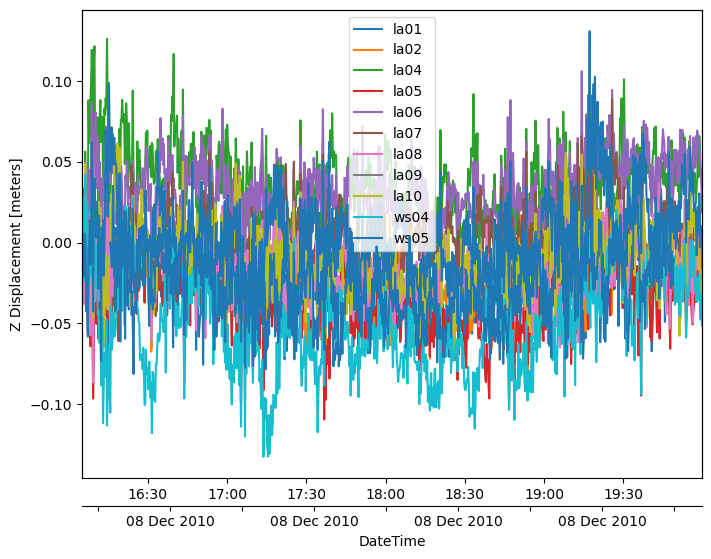

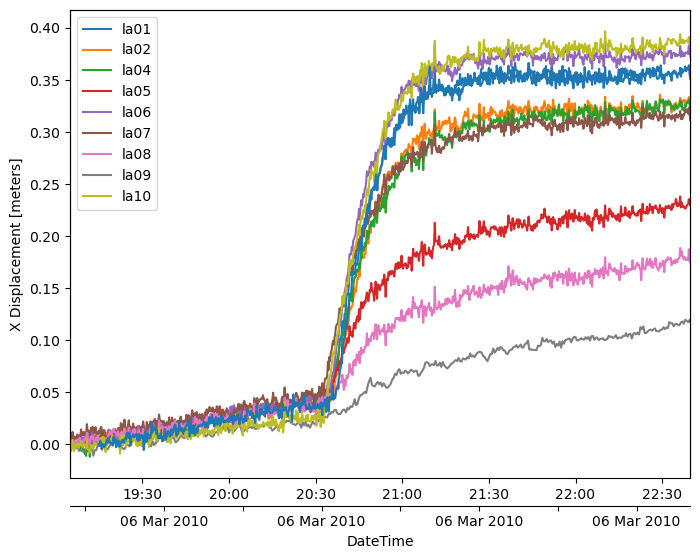

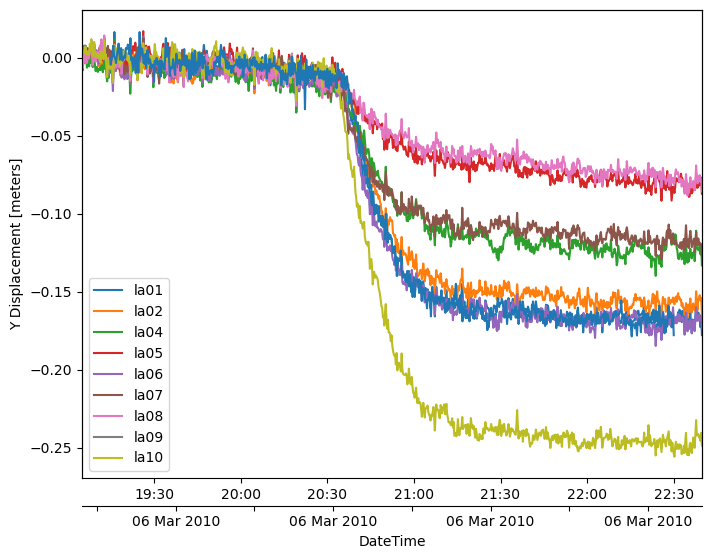

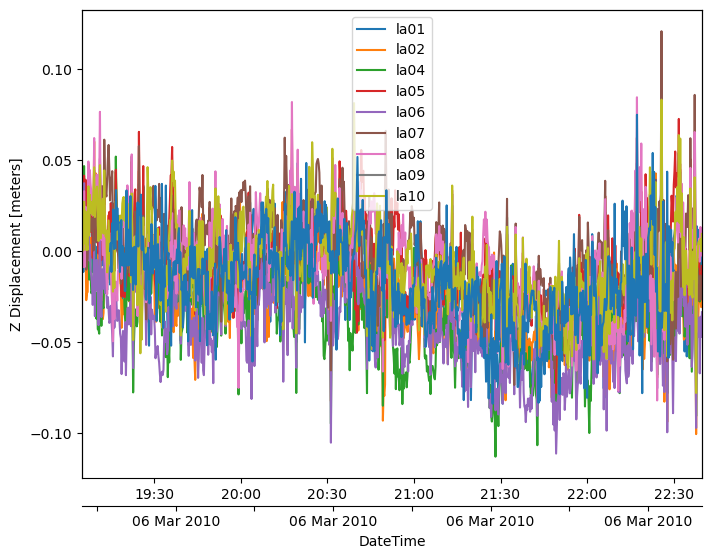

In [5]:
# Load and plot events
start = 40
end = 42

for evt_path in os.listdir(evts_path)[start:end]:
    print(f"Loading {evt_path}")
    event = pd.read_csv(os.path.join(evts_path, evt_path), sep="\t")
    plot_event(event, var="x")
    plot_event(event, var="y")
    plot_event(event, var="z")

In [6]:
# storing events in data frame for use
events_list = []

for evt_path in os.listdir(evts_path):
    full_path = os.path.join(evts_path, evt_path)
    print(f"Loading {evt_path}")
    event = pd.read_csv(full_path, sep="\t")
        
    events_list.append(event)

Loading 2010-11-18_23-03-00.evt
Loading 2010-08-09_01-24-45.evt
Loading 2010-03-13_00-28-30.evt
Loading 2010-02-18_08-46-45.evt
Loading 2010-06-24_08-31-00.evt
Loading 2010-06-17_14-04-45.evt
Loading 2010-09-20_20-30-30.evt
Loading 2010-09-04_22-31-30.evt
Loading 2010-05-06_21-24-45.evt
Loading 2010-02-22_19-26-45.evt
Loading 2010-07-15_12-19-45.evt
Loading 2010-06-01_04-24-45.evt
Loading 2010-12-14_11-10-00.evt
Loading 2010-11-07_14-18-00.evt
Loading 2010-12-04_21-10-00.evt
Loading 2010-10-06_06-29-45.evt
Loading 2010-03-14_21-05-00.evt
Loading 2010-10-29_18-28-00.evt
Loading 2010-01-20_14-16-45.evt
Loading 2010-06-25_01-09-45.evt
Loading 2010-09-22_10-24-45.evt
Loading 2010-04-03_05-07-00.evt
Loading 2010-06-17_04-19-45.evt
Loading 2010-02-01_10-46-45.evt
Loading 2010-07-23_10-00-30.evt
Loading 2010-03-09_18-10-00.evt
Loading 2010-03-26_19-01-45.evt
Loading 2010-05-17_04-04-45.evt
Loading 2010-01-15_15-30-00.evt
Loading 2010-01-11_20-34-45.evt
Loading 2010-11-06_23-33-00.evt
Loading 

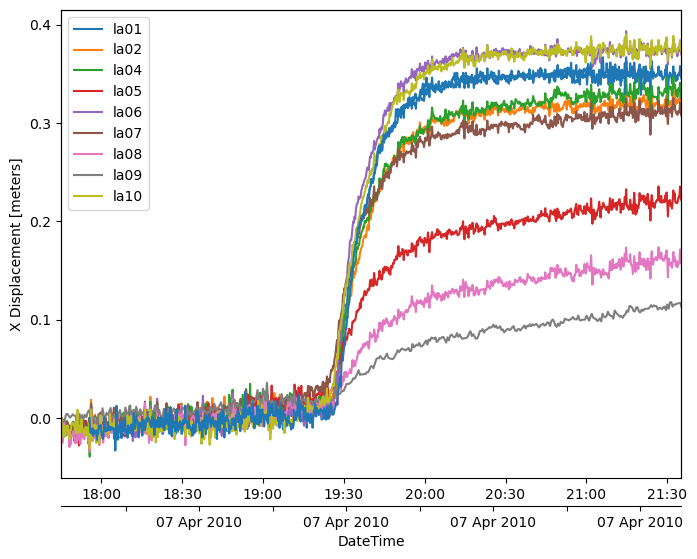

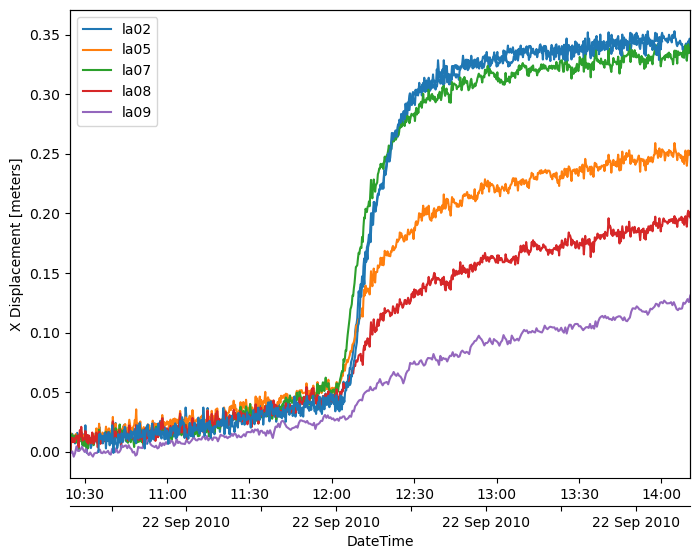

In [7]:
plot_event(events_list[50], var = 'x')
plot_event(events_list[20], var = 'x')


In [17]:
import scipy.signal # butterworh, filt filt

# Parameters for derivative
order_1st = 4
crit_1st = 0.1
order_2nd = 4
crit_2nd = 0.05
spacing = 15  # seconds between samples
 
max_second_derivs = []  # Will hold one dictionary per event

def compute_derivative(signal):
    y = signal - np.mean(signal)
    b, a = scipy.signal.butter(order_1st, crit_1st)
    first_deriv = scipy.signal.filtfilt(b, a, y, padlen=50)
    grad1 = np.gradient(first_deriv, spacing)

    b2, a2 = scipy.signal.butter(order_2nd, crit_2nd)
    second_filtered = scipy.signal.filtfilt(b2, a2, grad1, padlen=50)
    grad2 = np.gradient(second_filtered, spacing)
    return grad2

for i, eventsdf in enumerate(events_list):
    result = {"event_index": i}
    x_cols = [col for col in event if col.endswith("x")]

    for col in x_cols:
        if not (np.isnan(eventsdf[col].iloc[0]) or np.isnan(eventsdf[col].iloc[-1])):
            grad2 = compute_derivative(eventsdf[col].values)
            result[col] = np.nanmax(np.abs(grad2))  # Max magnitude of 2nd deriv

    max_second_derivs.append(result)

/var/folders/zg/jhrvqkbd33x0c7lyzw9rdfsc0000gn/T/ipykernel_95119/3946300237.py:30: RuntimeWarning: All-NaN slice encountered
  result[col] = np.nanmax(np.abs(grad2))  # Max magnitude of 2nd deriv


In [19]:
max_second_derivs

[{'event_index': 0,
  'la01x': 7.093311861411978e-07,
  'la02x': 6.413789912266645e-07,
  'la04x': 7.537235235504516e-07,
  'la05x': 4.0000173839930874e-07,
  'la06x': 1.0996119961722754e-06,
  'la07x': 7.596454095544397e-07,
  'la08x': 2.851281137783653e-07,
  'la09x': 4.880445605702387e-07,
  'la10x': 7.997298491760003e-07},
 {'event_index': 1,
  'la02x': 1.6629661328831534e-06,
  'la09x': 3.3573461578838027e-07},
 {'event_index': 2,
  'la01x': 7.23611144794068e-07,
  'la02x': 4.847115913945224e-07,
  'la04x': 7.983601707612803e-07,
  'la05x': 3.3484576016484075e-07,
  'la06x': 7.939573910169887e-07,
  'la07x': 5.06260923042034e-07,
  'la08x': 4.065522537594023e-07,
  'la09x': 9.417623301508894e-07,
  'la10x': 7.672379613518796e-07},
 {'event_index': 3,
  'la01x': 1.3566091809143904e-06,
  'la02x': 1.2049950017315744e-06,
  'la04x': 1.2528132139809271e-06,
  'la05x': 5.751049932078656e-07,
  'la06x': 1.6225323473092994e-06,
  'la07x': 1.1217500835571002e-06,
  'la08x': 4.952552021315

In [21]:
#caluculate the average 2n derivs
averagederivs = []
for dictionary in max_second_derivs:
    values = [v for k, v in dictionary.items() if k != "event_index"]
    avg = np.mean(values)
    averagederivs.append(avg)


In [22]:
series = pd.Series(averagederivs)
series.describe()


count    5.140000e+02
mean     9.667474e-07
std      2.811000e-07
min      3.214559e-07
25%      7.608146e-07
50%      9.235802e-07
75%      1.121638e-06
max      1.719483e-06
dtype: float64

In [23]:
max_index = series.idxmax()
min_index = series.idxmin()
print(series.nsmallest(2).index[1])

401


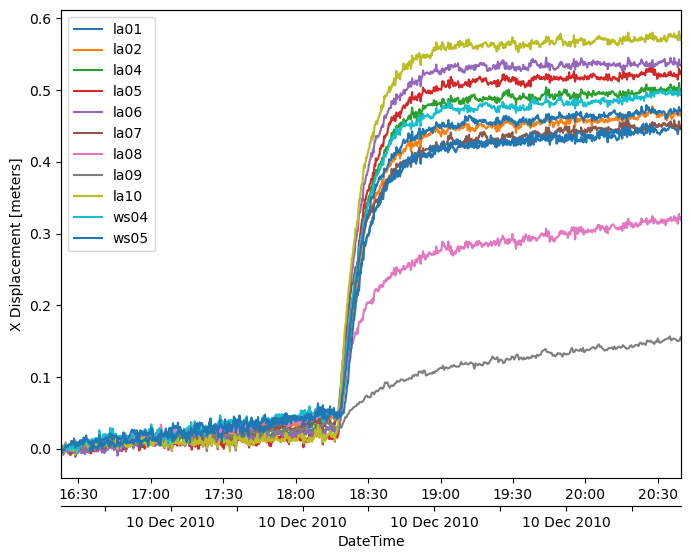

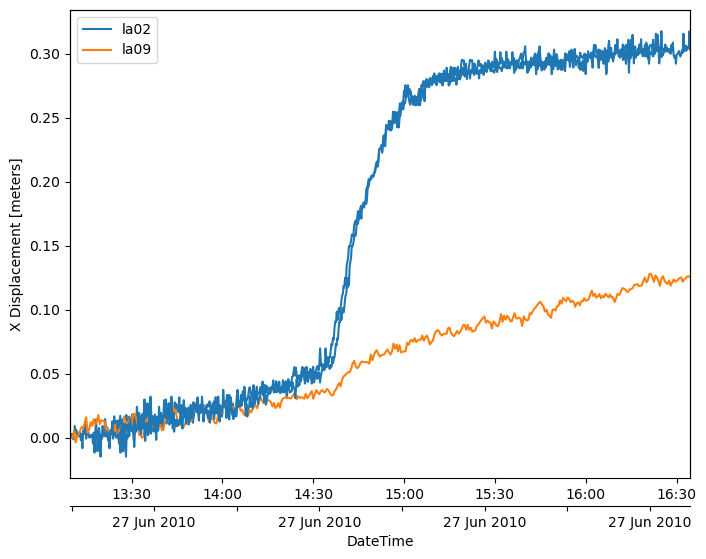

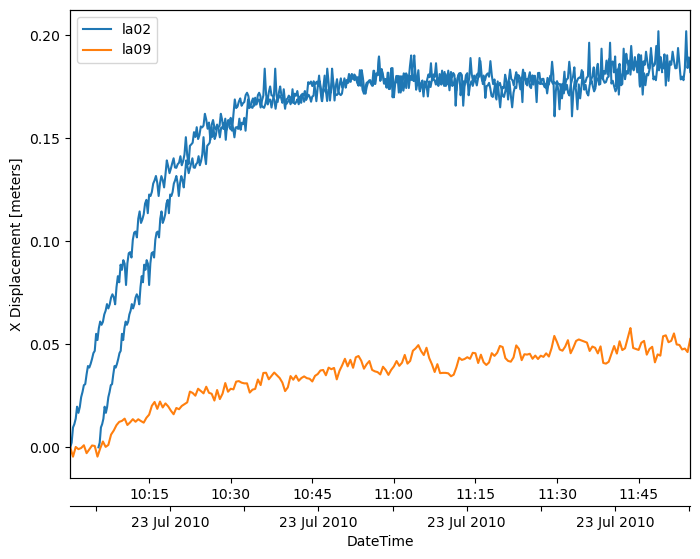

In [24]:
# view graphs for the 188 and 24,188 events

plot_event(events_list[188], var = 'x')
plot_event(events_list[401], var = 'x')
plot_event(events_list[24], var = 'x')

In [25]:
events_list[188].describe()

,Unnamed: 0,la01x,la01y,la01z,la01res,la01res_avg,la02x,la02y,la02z,la02res,...,ws05res,ws05res_avg,slw1x,slw1y,slw1z,slw1res,slw1res_avg,sum_res_avg,ressum,event
count,1.028000e+03,1028.000000,1028.000000,1028.000000,1028.000000,1.028000e+03,1028.000000,1028.000000,1028.000000,1028.000000,...,1028.000000,1.028000e+03,0.0,0.0,0.0,0.0,0.0,1.028000e+03,1028.000000,1028.0
mean,1.979934e+06,-283576.876404,-560178.631538,93.786332,1.899668,3.329376e-01,-277696.964087,-560509.644509,92.826042,2.283773,...,0.378671,6.569714e-02,NaN,NaN,NaN,NaN,NaN,3.133612e+00,18.491483,1.0
std,2.969023e+02,0.195174,0.091814,0.020470,0.869431,4.498592e-15,0.208439,0.101075,0.018501,1.046518,...,0.432630,1.041341e-15,NaN,NaN,NaN,NaN,NaN,3.776596e-14,9.373951,0.0
min,1.979421e+06,-283577.112812,-560178.743257,93.714300,0.345812,3.329376e-01,-277697.216042,-560509.762418,92.757700,0.388575,...,0.003323,6.569714e-02,NaN,NaN,NaN,NaN,NaN,3.133612e+00,3.170062,1.0
25%,1.979678e+06,-283577.081248,-560178.724215,93.772625,1.196878,3.329376e-01,-277697.183258,-560509.746158,92.813900,1.435427,...,0.005145,6.569714e-02,NaN,NaN,NaN,NaN,NaN,3.133612e+00,10.711265,1.0
50%,1.979934e+06,-283576.794178,-560178.670197,93.786150,1.874477,3.329376e-01,-277696.873067,-560509.689921,92.826100,2.254882,...,0.151358,6.569714e-02,NaN,NaN,NaN,NaN,NaN,3.133612e+00,17.250009,1.0
75%,1.980191e+06,-283576.679951,-560178.535425,93.798900,2.670968,3.329376e-01,-277696.754014,-560509.538585,92.838100,3.223683,...,0.717463,6.569714e-02,NaN,NaN,NaN,NaN,NaN,3.133612e+00,26.610199,1.0
max,1.980448e+06,-283576.655843,-560178.516175,93.858900,3.266464,3.329376e-01,-277696.729764,-560509.518507,92.885000,3.930273,...,1.263138,6.569714e-02,NaN,NaN,NaN,NaN,NaN,3.133612e+00,34.202086,1.0


In [26]:
events_list[401].describe()

,Unnamed: 0,la01x,la01y,la01z,la01res,la01res_avg,la02x,la02y,la02z,la02res,...,ws05res,ws05res_avg,slw1x,slw1y,slw1z,slw1res,slw1res_avg,sum_res_avg,ressum,event
count,8.200000e+02,0.0,0.0,0.0,0.0,0.0,820.000000,820.000000,820.000000,820.000000,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8.200000e+02,820.000000,820.0
mean,1.022924e+06,NaN,NaN,NaN,NaN,NaN,-277847.222385,-560438.322471,92.761865,0.785746,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.097865e-01,0.796952,1.0
std,2.368579e+02,NaN,NaN,NaN,NaN,NaN,0.127741,0.062971,0.020698,0.238828,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.499716e-15,0.240848,0.0
min,1.022515e+06,NaN,NaN,NaN,NaN,NaN,-277847.404041,-560438.420073,92.671100,0.405438,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.097865e-01,0.411844,1.0
25%,1.022720e+06,NaN,NaN,NaN,NaN,NaN,-277847.362374,-560438.383429,92.749275,0.582145,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.097865e-01,0.593685,1.0
50%,1.022924e+06,NaN,NaN,NaN,NaN,NaN,-277847.163728,-560438.354366,92.761900,0.770534,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.097865e-01,0.780269,1.0
75%,1.023129e+06,NaN,NaN,NaN,NaN,NaN,-277847.096856,-560438.253013,92.773675,0.999113,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.097865e-01,1.011706,1.0
max,1.023334e+06,NaN,NaN,NaN,NaN,NaN,-277847.071576,-560438.231841,92.860800,1.155254,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.097865e-01,1.169654,1.0


In [27]:
type(eventsdf)

pandas.core.frame.DataFrame